In [9]:
import polars as pl
from polars import col as c
import matplotlib.pyplot as plt

In [2]:
lf = pl.scan_parquet('../data/processed/prices.parquet')

In [3]:
df = lf.filter(
    pl.col('ticker').is_in(['A', 'AAPL'])
).collect()

df = lf.collect()

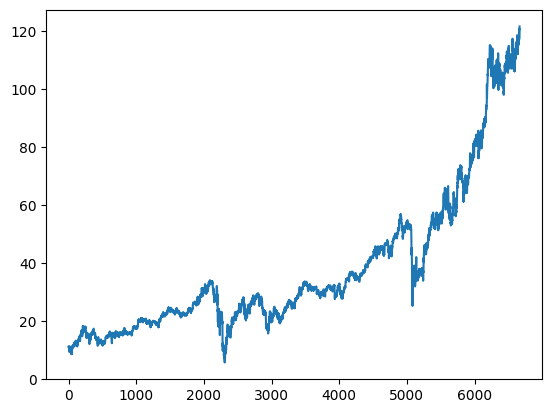

In [33]:
plt.plot(df.filter(c('ticker').is_in(['AFL']))['close'])

In [5]:
df.describe()

statistic,ticker,date,open,high,low,close,volume
str,str,str,f64,f64,f64,f64,f64
"""count""","""2917517""","""2917517""",2.917517e6,2.917517e6,2.917517e6,2.917517e6,2.917517e6
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0
"""mean""",null,"""2014-01-27 09:58:18.835345""",85.111451,86.11896,84.082275,85.122508,8.5368e6
"""std""",null,null,198.358845,200.748997,195.980598,198.367029,4.7475e7
"""min""","""A""","""2000-01-03""",0.030208,0.030521,0.026979,0.030521,0.0
"""25%""",null,"""2007-09-25""",23.629999,23.95652,23.299999,23.629999,953400.0
"""50%""",null,"""2014-06-23""",45.66,46.189999,45.119999,45.669998,2.23771e6
"""75%""",null,"""2020-08-19""",89.559998,90.540001,88.548111,89.5625,5.4445e6
"""max""","""ZTS""","""2026-07-08""",9914.169922,9964.769531,9794.0,9924.400391,9.2309e9


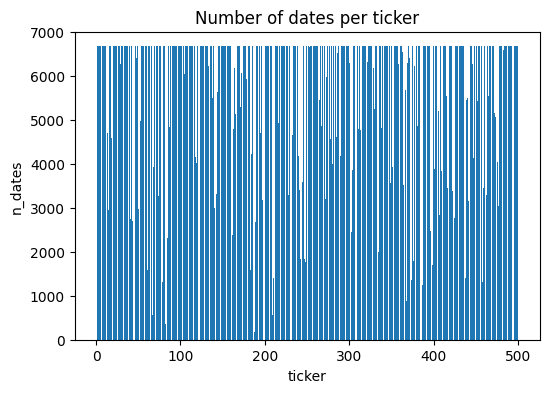

In [22]:
n_tickers = df.group_by('ticker').len()

f, ax = plt.subplots(1, figsize=(6, 4))
plt.bar(range(len(n_tickers)), n_tickers['len'])
plt.xlabel('ticker')
plt.ylabel('n_dates')
plt.title('Number of dates per ticker');